In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA

# -----------------------------
# 1. 금리 커브 데이터 로드 & 머지
# -----------------------------

# FRED에서 받은 csv 파일 이름들
yield_files = [
    "DGS1MO.csv",
    "DGS3MO.csv",
    "DGS6MO.csv",
    "DGS1.csv",
    "DGS2.csv",
    "DGS3.csv",
    "DGS5.csv",
    "DGS7.csv",
    "DGS10.csv",
    "DGS20.csv",
    "DGS30.csv",
]

dfs = []

for fname in yield_files:
    # 파일 읽기
    tmp = pd.read_csv(fname)
    # 날짜를 datetime으로 변환
    tmp["observation_date"] = pd.to_datetime(tmp["observation_date"])
    
    # value 컬럼 이름 (예: DGS3.csv -> DGS3)
    # 보통 csv 안의 컬럼 이름이 파일명과 같지만, 혹시 몰라서 한 번 더 맞춰줌
    col_candidates = [c for c in tmp.columns if c != "observation_date"]
    if len(col_candidates) != 1:
        raise ValueError(f"{fname}에서 값 컬럼을 하나로 찾지 못했습니다: {col_candidates}")
    value_col = col_candidates[0]

    # 컬럼 이름을 파일명(확장자 제외)로 통일
    new_col_name = fname.replace(".csv", "")
    tmp = tmp.rename(columns={value_col: new_col_name})
    
    dfs.append(tmp)

# observation_date 기준으로 머지 (inner join: 모든 만기가 있는 날짜만 사용)
curve = dfs[0]
for tmp in dfs[1:]:
    curve = curve.merge(tmp, on="observation_date", how="inner")

# 인덱스를 날짜로 두고 정렬
curve = curve.sort_values("observation_date").set_index("observation_date")

# 숫자형으로 강제 변환 (혹시 문자열이 섞여 있으면 NaN으로)
curve = curve.apply(pd.to_numeric, errors="coerce")

# PCA를 위해 NaN이 있는 날짜는 제거
curve_clean = curve.dropna(how="any")

print("커브 데이터 형태:", curve_clean.shape)
print(curve_clean.head())

# -----------------------------
# 2. PCA로 Level / Slope / Curvature 추출
# -----------------------------

# sklearn의 PCA는 자동으로 각 컬럼을 평균 제거(centering)해줌
pca = PCA(n_components=3)  # 첫 3개 주성분만
pcs = pca.fit_transform(curve_clean.values)

# 주성분 스코어 DataFrame (각 날짜별 level/slope/curvature)
pc_cols = ["PC1_level", "PC2_slope", "PC3_curvature"]
curve_pcs = pd.DataFrame(pcs, index=curve_clean.index, columns=pc_cols)

print("\nPCA 설명분산비율 (각 팩터가 전체 변동성을 얼마나 설명하는지):")
for name, var in zip(pc_cols, pca.explained_variance_ratio_):
    print(f"  {name}: {var:.4f}")

print("\n주성분 로딩(만기별 가중치)도 보고 싶으면 아래 주석을 해제해서 확인하세요.")
# loadings = pd.DataFrame(
#     pca.components_.T,
#     index=curve_clean.columns,
#     columns=pc_cols
# )
# print(loadings)

# -----------------------------
# 3. FOMC statement/minutes 데이터 전처리
# -----------------------------

# fomc_statement_minutes 파일 읽기 (같은 디렉토리에 있다고 가정)
fomc = pd.read_excel("fomc_statement_minutes.xlsx")

# meeting_id 예: 'FOMC_20060131' 형태 -> 뒤의 8자리 날짜만 추출
fomc["meeting_id"] = fomc["meeting_id"].astype(str)

# 숫자 8자리 추출 (대소문자 상관없음)
date_str = fomc["meeting_id"].str.extract(r"(\d{8})")[0]
fomc["meeting_date"] = pd.to_datetime(date_str, format="%Y%m%d")

# 필요하면 statement / minutes만 따로 필터링
fomc_statement = fomc[fomc["doc_type"].str.lower() == "statement"].copy()
fomc_minutes   = fomc[fomc["doc_type"].str.lower() == "minutes"].copy()

print("\nFOMC statement 예시 행:")
print(fomc_statement[["meeting_id", "meeting_date"]].head())

# -----------------------------
# 4. FOMC 날짜와 커브/PCA 매칭 예시
# -----------------------------

# 예: statement 날짜의 커브 수준과 PCA 팩터를 가져오기
# (정확한 이벤트 윈도우 정의는 나중에: 전일/당일, 30분 전후 등)

# 커브 원 데이터에서 해당 날짜의 수익률
statement_curve = curve_clean.reindex(fomc_statement["meeting_date"])
# PCA 팩터
statement_pcs = curve_pcs.reindex(fomc_statement["meeting_date"])

# 두 개를 하나의 DataFrame으로 합치고 싶으면:
statement_merged = (
    fomc_statement[["meeting_id", "meeting_date", "doc_type"]]
    .set_index("meeting_date")
    .join(statement_curve)
    .join(statement_pcs)
)

print("\nFOMC statement 날짜에 매칭된 커브 + PCA 예시:")
print(statement_merged.head())


커브 데이터 형태: (4971, 11)
                  DGS1MO  DGS3MO  DGS6MO  DGS1  DGS2  DGS3  DGS5  DGS7  DGS10  \
observation_date                                                                
2006-01-03          4.05    4.16    4.40  4.38  4.34  4.30  4.30  4.32   4.37   
2006-01-04          4.03    4.19    4.37  4.35  4.31  4.28  4.28  4.31   4.36   
2006-01-05          4.05    4.20    4.37  4.36  4.32  4.29  4.29  4.31   4.36   
2006-01-06          4.06    4.22    4.39  4.38  4.36  4.32  4.32  4.33   4.38   
2006-01-09          4.09    4.23    4.40  4.39  4.36  4.32  4.32  4.34   4.38   

                  DGS20  DGS30  
observation_date                
2006-01-03         4.62   4.52  
2006-01-04         4.60   4.55  
2006-01-05         4.61   4.51  
2006-01-06         4.63   4.53  
2006-01-09         4.63   4.53  

PCA 설명분산비율 (각 팩터가 전체 변동성을 얼마나 설명하는지):
  PC1_level: 0.9198
  PC2_slope: 0.0684
  PC3_curvature: 0.0097

주성분 로딩(만기별 가중치)도 보고 싶으면 아래 주석을 해제해서 확인하세요.

FOMC statement 예시 행:
      meet

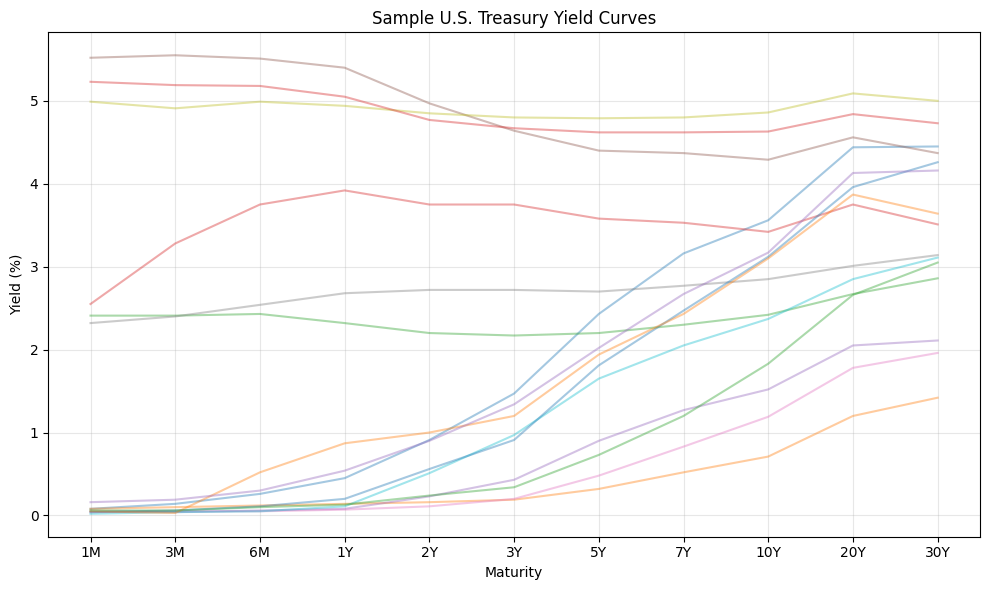

In [14]:
import matplotlib.pyplot as plt

# 1) 만기 순서와 라벨 정의
maturity_cols = [
    "DGS1MO",
    "DGS3MO",
    "DGS6MO",
    "DGS1",
    "DGS2",
    "DGS3",
    "DGS5",
    "DGS7",
    "DGS10",
    "DGS20",
    "DGS30",
]

# 사람이 보기 좋은 x축 라벨 (월/년)
maturity_labels = ["1M", "3M", "6M", "1Y", "2Y", "3Y", "5Y", "7Y", "10Y", "20Y", "30Y"]

# 혹시 컬럼 순서가 섞여있다면 이 순서대로 재정렬
curve_plot = curve_clean[maturity_cols]

# 2) 임의의 날짜 15개 정도 샘플링해서 커브 그리기
sample_curves = curve_plot.sample(15, random_state=42)

plt.figure(figsize=(10, 6))

for idx, row in sample_curves.iterrows():
    plt.plot(maturity_labels, row.values, alpha=0.4)

plt.title("Sample U.S. Treasury Yield Curves")
plt.xlabel("Maturity")
plt.ylabel("Yield (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


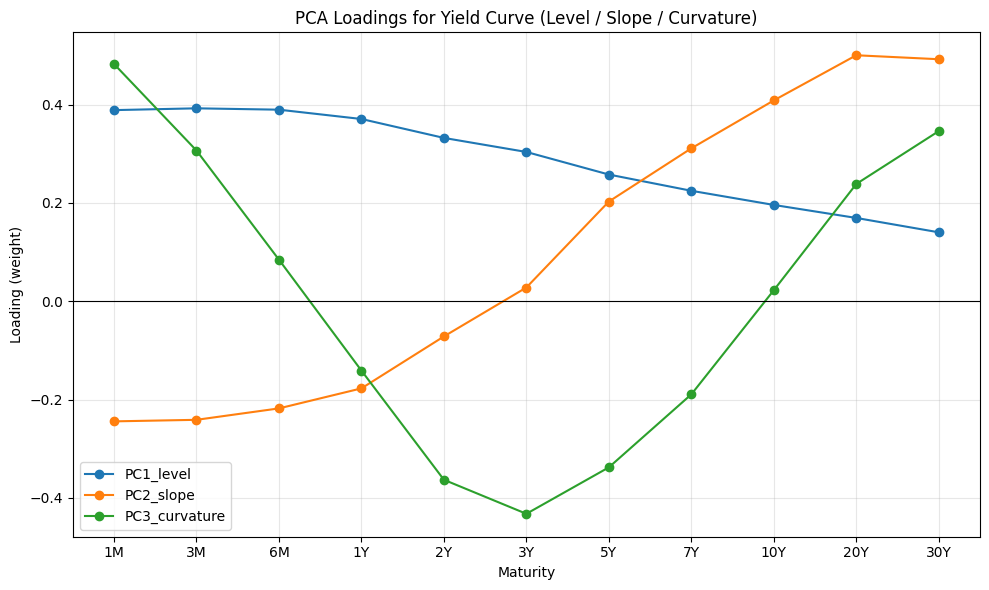

In [15]:
import matplotlib.pyplot as plt

# 주성분 이름
pc_cols = ["PC1_level", "PC2_slope", "PC3_curvature"]

# PCA 로딩 (만기별 가중치)
loadings = pd.DataFrame(
    pca.components_.T,          # shape: (n_features, n_components)
    index=curve_clean.columns,  # 각 만기 컬럼 이름
    columns=pc_cols
)

# 만기를 보기 좋은 순서로 다시 정렬
loadings = loadings.loc[maturity_cols]

plt.figure(figsize=(10, 6))

for pc in pc_cols:
    plt.plot(maturity_labels, loadings[pc].values, marker="o", label=pc)

plt.axhline(0, color="black", linewidth=0.8)
plt.title("PCA Loadings for Yield Curve (Level / Slope / Curvature)")
plt.xlabel("Maturity")
plt.ylabel("Loading (weight)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
'''  
“PCA로 추출된 첫 번째 요인은 모든 만기에서 양(+)의 로딩을 가지므로
금리커브 전체의 레벨 이동을 의미합니다.
두 번째 요인은 단기와 장기가 서로 반대 부호를 가져,
기울기(Slope) 변화를 설명하고,
세 번째 요인은 중간 만기에서만 크게 나타나 Curvature를 포착합니다.”
'''

In [2]:
'''  
PCA 설명분산비율 (각 팩터가 전체 변동성을 얼마나 설명하는지):
  PC1_level: 0.9198
  PC2_slope: 0.0684
  PC3_curvature: 0.0097
  
  미국 국채 커브는 거의 대부분 레벨(전체 높이)과 슬로프(단기 vs 장기) 두 축으로 설명되고, 
  곡률은 상대적으로 작다
  -> 금리 커브 문헌에서 나오는 전형적인 패턴과 비슷한 결과(고려대) '''

'  \nPCA 설명분산비율 (각 팩터가 전체 변동성을 얼마나 설명하는지):\n  PC1_level: 0.9198\n  PC2_slope: 0.0684\n  PC3_curvature: 0.0097\n\n  미국 국채 커브는 거의 대부분 레벨(전체 높이)과 슬로프(단기 vs 장기) 두 축으로 설명되고, \n  곡률은 상대적으로 작다\n  -> 금리 커브 문헌에서 나오는 전형적인 패턴과 비슷한 결과(고려대) '

In [2]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from pandas.tseries.offsets import BDay

# =========================================================
# 1. 미 국채 커브 데이터 로드 + PCA (Level / Slope / Curvature)
# =========================================================

yield_files = [
    "DGS1MO.csv",
    "DGS3MO.csv",
    "DGS6MO.csv",
    "DGS1.csv",
    "DGS2.csv",
    "DGS3.csv",
    "DGS5.csv",
    "DGS7.csv",
    "DGS10.csv",
    "DGS20.csv",
    "DGS30.csv",
]

dfs = []
for fname in yield_files:
    df = pd.read_csv(fname)
    df["observation_date"] = pd.to_datetime(df["observation_date"])

    # 값 컬럼(금리) 이름 찾아서 파일명으로 맞추기
    value_cols = [c for c in df.columns if c != "observation_date"]
    if len(value_cols) != 1:
        raise ValueError(f"{fname}에서 값 컬럼이 1개가 아닙니다: {value_cols}")
    value_col = value_cols[0]

    series_name = fname.replace(".csv", "")  # 예: 'DGS3.csv' -> 'DGS3'
    df = df.rename(columns={value_col: series_name})
    dfs.append(df)

# observation_date 기준으로 모두 inner join
curve = dfs[0]
for df in dfs[1:]:
    curve = curve.merge(df, on="observation_date", how="inner")

# 날짜를 인덱스로, 오름차순 정렬
curve = curve.sort_values("observation_date").set_index("observation_date")

# 숫자형으로 변환, NaN이 있는 날짜 제거
curve = curve.apply(pd.to_numeric, errors="coerce")
curve_clean = curve.dropna(how="any")

# 혹시라도 중복 날짜가 있다면 첫 번째 것만 사용
curve_clean = curve_clean[~curve_clean.index.duplicated(keep="first")]

print("curve_clean shape:", curve_clean.shape)

# ------------------ PCA 수행 ------------------

pca = PCA(n_components=3)
pcs = pca.fit_transform(curve_clean.values)

pc_cols = ["PC1_level", "PC2_slope", "PC3_curvature"]
curve_pcs = pd.DataFrame(pcs, index=curve_clean.index, columns=pc_cols)

print("\nPCA 설명분산비율:")
for name, var in zip(pc_cols, pca.explained_variance_ratio_):
    print(f"  {name}: {var:.4f}")

# PC1 시계열 (index: 날짜, 값: Level factor)
pc1 = curve_pcs["PC1_level"]

# 혹시라도 중복 인덱스가 섞여 있으면 평균내서 unique index로 만들기
pc1 = pc1.groupby(level=0).mean()

# =========================================================
# 2. FOMC statement 데이터 로드 + 날짜 전처리
# =========================================================

fomc = pd.read_excel("fomc_statement_minutes.xlsx")

# meeting_id에서 YYYYMMDD 추출
fomc["meeting_id"] = fomc["meeting_id"].astype(str)
date_str = fomc["meeting_id"].str.extract(r"(\d{8})")[0]
fomc["meeting_date"] = pd.to_datetime(date_str, format="%Y%m%d")

# doc_type이 있다면 statement만 사용 (없으면 이 줄을 주석 처리)
if "doc_type" in fomc.columns:
    fomc["doc_type"] = fomc["doc_type"].astype(str)
    fomc_statement = fomc[fomc["doc_type"].str.lower() == "statement"].copy()
else:
    # 없으면 전체를 statement라고 가정
    fomc_statement = fomc.copy()

# 같은 날짜에 여러 행이 있으면 한 개만 남김
fomc_statement = fomc_statement.sort_values("meeting_date")
fomc_statement = fomc_statement.drop_duplicates(subset=["meeting_date"], keep="first")

# =========================================================
# 3. 전날 / 당일 PC1_level 붙이기
# =========================================================

# 영업일 기준 하루 전 날짜
fomc_statement["date_prev"] = fomc_statement["meeting_date"] - BDay(1)

# 당일 / 전날 PC1 값을 reindex로 가져오기
# (pc1은 이미 unique index라서 reindex 에러 없음)
fomc_statement["PC1_post"] = pc1.reindex(fomc_statement["meeting_date"]).values
fomc_statement["PC1_pre"]  = pc1.reindex(fomc_statement["date_prev"]).values

# 전/후 둘 중 하나라도 NaN이면 사용 불가 → 제거
fomc_pca_events = fomc_statement.dropna(subset=["PC1_pre", "PC1_post"]).copy()

# ΔPC1 계산 (당일 - 전날)
fomc_pca_events["delta_PC1"] = (
    fomc_pca_events["PC1_post"] - fomc_pca_events["PC1_pre"]
)

print("\nFOMC 이벤트 예시 (PC1_pre, PC1_post, delta_PC1):")
print(
    fomc_pca_events[["meeting_id", "date_prev", "meeting_date",
                     "PC1_pre", "PC1_post", "delta_PC1"]].head()
)

# =========================================================
# 4. ΔPC1으로 매파 / 비둘기 라벨 만들기
# =========================================================

# 임계값 tau 설정 (예: 표준편차의 0.5배)
std_delta = fomc_pca_events["delta_PC1"].std()
tau = 0.5 * std_delta

print("\nΔPC1 표준편차:", std_delta)
print("임계값 tau:", tau)

def label_from_delta(x, tau):
    if x > tau:
        return 1   # Hawkish (매파)
    elif x < -tau:
        return -1  # Dovish (비둘기)
    else:
        return 0   # Neutral / 작은 움직임

fomc_pca_events["label_pca_PC1"] = fomc_pca_events["delta_PC1"].apply(
    lambda x: label_from_delta(x, tau)
)

print("\n라벨 분포 (1=매파, -1=비둘기, 0=중립):")
print(fomc_pca_events["label_pca_PC1"].value_counts())

# 이진 분류용 데이터만 (중립 제외)
fomc_binary = fomc_pca_events[fomc_pca_events["label_pca_PC1"] != 0].copy()

print("\n이진 분류용 샘플 수:", len(fomc_binary))
print(fomc_binary[["meeting_id", "PC1_pre", "PC1_post",
                   "delta_PC1", "label_pca_PC1"]].head())


curve_clean shape: (4971, 11)

PCA 설명분산비율:
  PC1_level: 0.9198
  PC2_slope: 0.0684
  PC3_curvature: 0.0097


/opt/anaconda3/envs/TDM_lab/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/opt/anaconda3/envs/TDM_lab/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/opt/anaconda3/envs/TDM_lab/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T



FOMC 이벤트 예시 (PC1_pre, PC1_post, delta_PC1):
      meeting_id  date_prev meeting_date   PC1_pre  PC1_post  delta_PC1
0  FOMC_20060131 2006-01-30   2006-01-31  7.539228  7.604813   0.065585
2  FOMC_20060328 2006-03-27   2006-03-28  8.222288  8.427537   0.205249
4  FOMC_20060510 2006-05-09   2006-05-10  9.081148  9.096854   0.015706
6  FOMC_20060629 2006-06-28   2006-06-29  9.710848  9.541824  -0.169024
8  FOMC_20060808 2006-08-07   2006-08-08  9.240164  9.181452  -0.058712

ΔPC1 표준편차: 0.14905150186371777
임계값 tau: 0.07452575093185888

라벨 분포 (1=매파, -1=비둘기, 0=중립):
label_pca_PC1
 0    83
-1    55
 1    30
Name: count, dtype: int64

이진 분류용 샘플 수: 85
       meeting_id   PC1_pre  PC1_post  delta_PC1  label_pca_PC1
2   FOMC_20060328  8.222288  8.427537   0.205249              1
6   FOMC_20060629  9.710848  9.541824  -0.169024             -1
12  FOMC_20061025  9.126233  9.026377  -0.099856             -1
14  FOMC_20061212  8.351558  8.266908  -0.084650             -1
16  FOMC_20070131  9.150197  

In [7]:
# fomc_binary.head()

# fomc_binary.to_csv('fomc_binary.csv')

df = pd.read_csv('fomc_binary.csv')
df.head()

,Unnamed: 0,meeting_id,doc_type,source_url,text,meeting_date,date_prev,PC1_post,PC1_pre,delta_PC1,label_pca_PC1
0,2,FOMC_20060328,statement,https://www.federalreserve.gov/newsevents/pres...,"March 28, 2006\n\nFor immediate release\n\nThe...",2006-03-28,2006-03-27,8.427537,8.222288,0.205249,1
1,6,FOMC_20060629,statement,https://www.federalreserve.gov/newsevents/pres...,"June 29, 2006\n\nFor immediate release\n\nThe ...",2006-06-29,2006-06-28,9.541824,9.710848,-0.169024,-1
2,12,FOMC_20061025,statement,https://www.federalreserve.gov/newsevents/pres...,"October 25, 2006\n\nFor immediate release\n\nT...",2006-10-25,2006-10-24,9.026377,9.126233,-0.099856,-1
3,14,FOMC_20061212,statement,https://www.federalreserve.gov/newsevents/pres...,"December 12, 2006\n\nFor immediate release\n\n...",2006-12-12,2006-12-11,8.266908,8.351558,-0.084650,-1
4,16,FOMC_20070131,statement,https://www.federalreserve.gov/newsevents/pres...,"January 31, 2007\n\nFor immediate release\n\nT...",2007-01-31,2007-01-30,9.061943,9.150197,-0.088254,-1


In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# =========================================================
# 0. 전제: fomc_binary (라벨 + PCA 결과) 가 이미 메모리에 존재
#    필요하면 먼저 읽어오기:
#    fomc_binary = pd.read_csv("fomc_binary.csv",
#                              parse_dates=["meeting_date", "date_prev"])
# =========================================================

# ---------------------------------------------------------
# 1. FOMC 텍스트 파일 읽기
# ---------------------------------------------------------
fomc_text = pd.read_excel("fomc_statement_minutes.xlsx")
print(">>> fomc_text columns:", list(fomc_text.columns))

fomc_text["meeting_id"] = fomc_text["meeting_id"].astype(str)
fomc_text["doc_type"] = fomc_text["doc_type"].astype(str)

# statement만 사용
fomc_text_stmt = fomc_text[fomc_text["doc_type"].str.lower() == "statement"].copy()
print(">>> statement 행 개수:", len(fomc_text_stmt))

# ---------------------------------------------------------
# 2. 라벨 데이터(fomc_binary)와 텍스트 merge
# ---------------------------------------------------------
fomc_binary = fomc_binary.copy()
fomc_binary["meeting_id"] = fomc_binary["meeting_id"].astype(str)

print(">>> fomc_binary columns:", list(fomc_binary.columns))

# 텍스트 쪽은 meeting_id + text만 남김
fomc_text_stmt_slim = fomc_text_stmt[["meeting_id", "text"]].copy()
print(">>> fomc_text_stmt_slim columns:", list(fomc_text_stmt_slim.columns))

data = pd.merge(
    fomc_binary,
    fomc_text_stmt_slim,
    on="meeting_id",
    how="inner",
)

print(">>> merge 후 data columns:", list(data.columns))

# ---- 여기서 text 컬럼 정리 (중요 부분) ----
# 만약 이전에 다른 merge에서 텍스트가 들어와서 text_x, text_y가 있다면
if "text" not in data.columns:
    # 우선순위: text_y -> text_x
    if "text_y" in data.columns:
        data["text"] = data["text_y"]
    elif "text_x" in data.columns:
        data["text"] = data["text_x"]
    else:
        raise ValueError(
            f"'text' 컬럼이 없습니다. 현재 컬럼: {list(data.columns)}"
        )

# 사용 안 하는 text_x / text_y 있으면 정리
drop_cols = [c for c in ["text_x", "text_y"] if c in data.columns]
if drop_cols:
    data = data.drop(columns=drop_cols)

print(">>> text 정리 후 data columns:", list(data.columns))

# 텍스트 NaN → 빈 문자열로 채우기
data["text"] = data["text"].fillna("")
print(">>> 빈 텍스트 행 수:", (data["text"].str.len() == 0).sum())

# ---------------------------------------------------------
# 3. sanity check
# ---------------------------------------------------------
print("\n[라벨 분포] (1=매파, -1=비둘기, 0=중립)")
print(data["label_pca_PC1"].value_counts())

print("\n[라벨별 평균 PC1_pre, PC1_post, delta_PC1]")
print(
    data.groupby("label_pca_PC1")[["PC1_pre", "PC1_post", "delta_PC1"]].mean()
)

if (data["label_pca_PC1"] == 1).any():
    hawk_sample = data[data["label_pca_PC1"] == 1]["text"].iloc[0]
    print("\n[매파(1) 예시 텍스트 앞 400자]")
    print(hawk_sample[:400], "...\n")

if (data["label_pca_PC1"] == -1).any():
    dove_sample = data[data["label_pca_PC1"] == -1]["text"].iloc[0]
    print("[비둘기(-1) 예시 텍스트 앞 400자]")
    print(dove_sample[:400], "...\n")

# ---------------------------------------------------------
# 4. 모델링 준비 (중립 제거 → 이진 라벨)
# ---------------------------------------------------------
data_bin = data[data["label_pca_PC1"] != 0].copy()
data_bin["label_binary"] = data_bin["label_pca_PC1"].map({-1: 0, 1: 1})

X_text = data_bin["text"].values
y = data_bin["label_binary"].values

print("\n[이진 분류용 샘플 수]:", len(y))
print("클래스 분포 (0=비둘기, 1=매파):")
print(pd.Series(y).value_counts())

# ---------------------------------------------------------
# 5. train / test split
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("\ntrain 샘플 수:", len(X_train))
print("test 샘플 수:", len(X_test))

# ---------------------------------------------------------
# 6. TF-IDF 벡터화
# ---------------------------------------------------------
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("TF-IDF train shape:", X_train_vec.shape)

# ---------------------------------------------------------
# 7. 로지스틱 회귀 학습
# ---------------------------------------------------------
clf = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    n_jobs=-1,
)
clf.fit(X_train_vec, y_train)

# ---------------------------------------------------------
# 8. 평가
# ---------------------------------------------------------
y_pred = clf.predict(X_test_vec)

print("\n=== Confusion matrix (rows=true, cols=pred) ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification report (0=비둘기, 1=매파) ===")
print(classification_report(y_test, y_pred, digits=3))


>>> fomc_text columns: ['meeting_id', 'doc_type', 'source_url', 'text']
>>> statement 행 개수: 171
>>> fomc_binary columns: ['meeting_id', 'doc_type', 'source_url', 'text', 'meeting_date', 'date_prev', 'PC1_post', 'PC1_pre', 'delta_PC1', 'label_pca_PC1']
>>> fomc_text_stmt_slim columns: ['meeting_id', 'text']
>>> merge 후 data columns: ['meeting_id', 'doc_type', 'source_url', 'text_x', 'meeting_date', 'date_prev', 'PC1_post', 'PC1_pre', 'delta_PC1', 'label_pca_PC1', 'text_y']
>>> text 정리 후 data columns: ['meeting_id', 'doc_type', 'source_url', 'meeting_date', 'date_prev', 'PC1_post', 'PC1_pre', 'delta_PC1', 'label_pca_PC1', 'text']
>>> 빈 텍스트 행 수: 0

[라벨 분포] (1=매파, -1=비둘기, 0=중립)
label_pca_PC1
-1    55
 1    30
Name: count, dtype: int64

[라벨별 평균 PC1_pre, PC1_post, delta_PC1]
                PC1_pre  PC1_post  delta_PC1
label_pca_PC1                               
-1             1.542665  1.360772  -0.181893
 1            -0.380386 -0.217190   0.163196

[매파(1) 예시 텍스트 앞 400자]
March 28, 2006

F

In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report
from scipy.sparse import hstack, csr_matrix

# =====================================================
# 0. 전제
#  - curve_pcs : 날짜 index, columns = ['PC1_level','PC2_slope',...]
#  - data      : statement 텍스트 + Alpha 라벨 + meeting_date, date_prev, meeting_id
#    (앞에서 만든 merge 결과 DataFrame)
# =====================================================

# -----------------------------------------------------
# 1. Beta(PC2) 라벨 만들기 (statement 기준)
#    - Alpha 와 동일한 방식으로 PC2_slope 전/후 차이 → label_pca_PC2
# -----------------------------------------------------

from pandas.tseries.offsets import BDay

pc2 = curve_pcs["PC2_slope"].copy()
pc2 = pc2.groupby(level=0).mean()  # 혹시 중복 날짜 있으면 평균

# statement 이벤트에 맞춰 전/후 PC2 값 붙이기
data = data.copy()

data["PC2_post"] = pc2.reindex(data["meeting_date"]).values
data["PC2_pre"]  = pc2.reindex(data["date_prev"]).values

# 전/후 중 하나라도 NaN이면 사용 불가
data["delta_PC2"] = data["PC2_post"] - data["PC2_pre"]

# 임계값 tau2 설정 (표준편차 0.5배 예시)
std_delta2 = data["delta_PC2"].dropna().std()
tau2 = 0.5 * std_delta2
print("Beta(PC2) Δ 표준편차:", std_delta2, " / tau2:", tau2)

def label_from_delta(x, tau):
    if pd.isna(x):
        return np.nan
    if x > tau:
        return 1
    elif x < -tau:
        return -1
    else:
        return 0

data["label_pca_PC2"] = data["delta_PC2"].apply(lambda x: label_from_delta(x, tau2))

print("\nAlpha 라벨 분포:", data["label_pca_PC1"].value_counts())
print("Beta  라벨 분포:", data["label_pca_PC2"].value_counts())

# -----------------------------------------------------
# 2. (옵션) tone_index 데이터 merge
#    - tone_index.csv 파일에 meeting_id, tone_index 열이 있다고 가정
# -----------------------------------------------------

try:
    tone = pd.read_csv("tone_index.csv")
    tone["meeting_id"] = tone["meeting_id"].astype(str)
    data["meeting_id"] = data["meeting_id"].astype(str)
    data = pd.merge(
        data,
        tone[["meeting_id", "tone_index"]],
        on="meeting_id",
        how="left",
    )
    HAS_TONE = True
    print("\n>>> tone_index 병합 완료")
except FileNotFoundError:
    HAS_TONE = False
    print("\n>>> tone_index.csv 를 찾지 못했습니다. tone 관련 실험은 건너뜁니다.")

# =====================================================
# 3. 공통 유틸 함수들
# =====================================================

def make_xy_for_label(data, label_col):
    """
    특정 라벨 컬럼(Alpha/Beta)에 대해:
    - 중립(0) 및 NaN 제거
    - -1 → 0, 1 → 1 로 binary 라벨 생성
    - 텍스트 / tone_index 같이 묶어서 반환
    """
    df = data.copy()
    df = df.dropna(subset=[label_col])
    df = df[df[label_col] != 0]   # 중립 제거

    df["label_binary"] = df[label_col].map({-1: 0, 1: 1})
    X_text = df["text"].values
    y = df["label_binary"].values

    tone_values = None
    if HAS_TONE and "tone_index" in df.columns:
        tone_values = df[["tone_index"]].fillna(0.0).values

    return df, X_text, y, tone_values


def train_test_text_split(X_text, y, tone_values=None, test_size=0.2):
    """
    텍스트 + (옵션) tone_feature 를 같은 인덱스로 train/test 분할
    """
    X_train_text, X_test_text, y_train, y_test, idx_train, idx_test = train_test_split(
        X_text,
        y,
        np.arange(len(y)),
        test_size=test_size,
        random_state=42,
        stratify=y,
    )

    tone_train = tone_test = None
    if tone_values is not None:
        tone_train = tone_values[idx_train]
        tone_test = tone_values[idx_test]

    return X_train_text, X_test_text, y_train, y_test, tone_train, tone_test


def eval_metrics(y_test, y_pred):
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    return acc, f1


# =====================================================
# 4. 모델별 실험 함수들 (Statement Only)
# =====================================================

def run_tfidf_logreg(X_train_text, X_test_text, y_train, y_test):
    """TF-IDF(unigram+bigram) + 로지스틱 회귀"""
    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.9,
    )
    X_train_vec = vectorizer.fit_transform(X_train_text)
    X_test_vec = vectorizer.transform(X_test_text)

    clf = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1,
    )
    clf.fit(X_train_vec, y_train)
    y_pred = clf.predict(X_test_vec)
    return eval_metrics(y_test, y_pred)


def run_tfidf_svm(X_train_text, X_test_text, y_train, y_test):
    """TF-IDF(unigram+bigram) + Linear SVM"""
    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.9,
    )
    X_train_vec = vectorizer.fit_transform(X_train_text)
    X_test_vec = vectorizer.transform(X_test_text)

    clf = LinearSVC()
    clf.fit(X_train_vec, y_train)
    y_pred = clf.predict(X_test_vec)
    return eval_metrics(y_test, y_pred)


def run_lda_logreg(X_train_text, X_test_text, y_train, y_test, n_topics=20):
    """CountVectorizer + LDA 토픽 분포 + 로지스틱 회귀"""
    count_vect = CountVectorizer(min_df=2, max_df=0.9)
    X_train_counts = count_vect.fit_transform(X_train_text)
    X_test_counts = count_vect.transform(X_test_text)

    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        learning_method="batch",
    )
    X_train_lda = lda.fit_transform(X_train_counts)
    X_test_lda = lda.transform(X_test_counts)

    clf = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1,
    )
    clf.fit(X_train_lda, y_train)
    y_pred = clf.predict(X_test_lda)
    return eval_metrics(y_test, y_pred)


def run_lda_svm(X_train_text, X_test_text, y_train, y_test, n_topics=20):
    """CountVectorizer + LDA 토픽 분포 + Linear SVM"""
    count_vect = CountVectorizer(min_df=2, max_df=0.9)
    X_train_counts = count_vect.fit_transform(X_train_text)
    X_test_counts = count_vect.transform(X_test_text)

    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        learning_method="batch",
    )
    X_train_lda = lda.fit_transform(X_train_counts)
    X_test_lda = lda.transform(X_test_counts)

    clf = LinearSVC()
    clf.fit(X_train_lda, y_train)
    y_pred = clf.predict(X_test_lda)
    return eval_metrics(y_test, y_pred)


def run_tone_logreg(tone_train, tone_test, y_train, y_test):
    """tone_index 하나만 사용하는 로지스틱 회귀"""
    clf = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1,
    )
    clf.fit(tone_train, y_train)
    y_pred = clf.predict(tone_test)
    return eval_metrics(y_test, y_pred)


def run_tfidf_tone_logreg(X_train_text, X_test_text, tone_train, tone_test, y_train, y_test):
    """TF-IDF 벡터 + tone_index 를 합쳐서 로지스틱 회귀"""

    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.9,
    )
    X_train_vec = vectorizer.fit_transform(X_train_text)
    X_test_vec = vectorizer.transform(X_test_text)

    # sparse TF-IDF + dense tone_index 를 hstack
    tone_train_sparse = csr_matrix(tone_train)
    tone_test_sparse = csr_matrix(tone_test)

    X_train_all = hstack([X_train_vec, tone_train_sparse])
    X_test_all = hstack([X_test_vec, tone_test_sparse])

    clf = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1,
    )
    clf.fit(X_train_all, y_train)
    y_pred = clf.predict(X_test_all)
    return eval_metrics(y_test, y_pred)


# =====================================================
# 5. Alpha / Beta 각각에 대해 모든 모델 실행하고 표 만들기
# =====================================================

rows = []

for label_name, label_col in [("Alpha", "label_pca_PC1"), ("Beta", "label_pca_PC2")]:

    df_lab, X_text, y, tone_values = make_xy_for_label(data, label_col)
    print(f"\n===== {label_name} : 샘플 수 {len(df_lab)} =====")

    X_train_text, X_test_text, y_train, y_test, tone_train, tone_test = \
        train_test_text_split(X_text, y, tone_values=tone_values)

    # 1) TF-IDF + LogReg
    acc, f1 = run_tfidf_logreg(X_train_text, X_test_text, y_train, y_test)
    rows.append(["TF-IDF + LogReg", "unigram+bigram", label_name, acc, f1])

    # 2) TF-IDF + SVM
    acc, f1 = run_tfidf_svm(X_train_text, X_test_text, y_train, y_test)
    rows.append(["TF-IDF + SVM", "unigram+bigram", label_name, acc, f1])

    # 3) LDA + LogReg
    acc, f1 = run_lda_logreg(X_train_text, X_test_text, y_train, y_test)
    rows.append(["LDA + LogReg", "K topics", label_name, acc, f1])

    # 4) LDA + SVM
    acc, f1 = run_lda_svm(X_train_text, X_test_text, y_train, y_test)
    rows.append(["LDA + SVM", "K topics", label_name, acc, f1])

    if HAS_TONE and tone_train is not None:
        # 5) tone_index + LogReg
        acc, f1 = run_tone_logreg(tone_train, tone_test, y_train, y_test)
        rows.append(["tone_index + LogReg", "tone only", label_name, acc, f1])

        # 6) TF-IDF + tone_index + LogReg
        acc, f1 = run_tfidf_tone_logreg(X_train_text, X_test_text, tone_train, tone_test, y_train, y_test)
        rows.append(["TF-IDF+tone + LogReg", "TF-IDF + tone", label_name, acc, f1])

# 결과 DataFrame으로 정리 (Table S1 채울 때 참고)

results_df = pd.DataFrame(
    rows,
    columns=["Model", "Features", "LabelType", "Acc", "F1_weighted"],
)

print("\n=== Statement Only (Text=S), PCA Alpha/Beta 결과 ===")
print(results_df)

# 필요하면 엑셀/CSV로 저장
# results_df.to_csv("results_table_S1_statement_only.csv", index=False)


Beta(PC2) Δ 표준편차: 0.16597334865259913  / tau2: 0.08298667432629957

Alpha 라벨 분포: label_pca_PC1
-1    55
 1    30
Name: count, dtype: int64
Beta  라벨 분포: label_pca_PC2
-1    32
 0    31
 1    22
Name: count, dtype: int64

>>> tone_index.csv 를 찾지 못했습니다. tone 관련 실험은 건너뜁니다.

===== Alpha : 샘플 수 85 =====

===== Beta : 샘플 수 54 =====

=== Statement Only (Text=S), PCA Alpha/Beta 결과 ===
             Model        Features LabelType       Acc  F1_weighted
0  TF-IDF + LogReg  unigram+bigram     Alpha  0.470588     0.470588
1     TF-IDF + SVM  unigram+bigram     Alpha  0.529412     0.529412
2     LDA + LogReg        K topics     Alpha  0.588235     0.588235
3        LDA + SVM        K topics     Alpha  0.470588     0.458033
4  TF-IDF + LogReg  unigram+bigram      Beta  0.363636     0.339394
5     TF-IDF + SVM  unigram+bigram      Beta  0.363636     0.339394
6     LDA + LogReg        K topics      Beta  0.636364     0.598485
7        LDA + SVM        K topics      Beta  0.545455     0.449198


In [6]:
print(
    results_df
    .pivot(index=["Model","Features"], columns="LabelType", values=["Acc","F1_weighted"])
    .round(4)
)


                                   Acc         F1_weighted        
LabelType                        Alpha    Beta       Alpha    Beta
Model           Features                                          
LDA + LogReg    K topics        0.5882  0.6364      0.5882  0.5985
LDA + SVM       K topics        0.4706  0.5455      0.4580  0.4492
TF-IDF + LogReg unigram+bigram  0.4706  0.3636      0.4706  0.3394
TF-IDF + SVM    unigram+bigram  0.5294  0.3636      0.5294  0.3394


In [7]:
import pandas as pd
import numpy as np
from pandas.tseries.offsets import BDay

# =====================================================
# 1) minutes 텍스트 + Alpha/Beta 라벨 만들기
#    - meeting_id -> 날짜 추출
#    - minutes 발표일 전/후 PC1, PC2 차이로 라벨 생성
# =====================================================

fomc = pd.read_excel("fomc_statement_minutes.xlsx")

fomc["meeting_id"] = fomc["meeting_id"].astype(str)
fomc["doc_type"] = fomc["doc_type"].astype(str)

# meeting_id 안의 YYYYMMDD 를 날짜로 사용
date_str = fomc["meeting_id"].str.extract(r"(\d{8})")[0]
fomc["meeting_date"] = pd.to_datetime(date_str, format="%Y%m%d")

# minutes만 사용
minutes = fomc[fomc["doc_type"].str.lower() == "minutes"].copy()
minutes = minutes.sort_values("meeting_date")

# 전날(영업일 기준)
minutes["date_prev"] = minutes["meeting_date"] - BDay(1)

# PCA 팩터 시계열 (curve_pcs는 앞에서 만든 PCA 결과 DataFrame)
pc1 = curve_pcs["PC1_level"].groupby(level=0).mean()
pc2 = curve_pcs["PC2_slope"].groupby(level=0).mean()

# 전/후 PC1, PC2 붙이기
minutes["PC1_post"] = pc1.reindex(minutes["meeting_date"]).values
minutes["PC1_pre"]  = pc1.reindex(minutes["date_prev"]).values
minutes["PC2_post"] = pc2.reindex(minutes["meeting_date"]).values
minutes["PC2_pre"]  = pc2.reindex(minutes["date_prev"]).values

# 변화량
minutes["delta_PC1"] = minutes["PC1_post"] - minutes["PC1_pre"]
minutes["delta_PC2"] = minutes["PC2_post"] - minutes["PC2_pre"]

# 임계값 (표준편차의 0.5배 예시)
std1 = minutes["delta_PC1"].dropna().std()
std2 = minutes["delta_PC2"].dropna().std()
tau1 = 0.5 * std1
tau2 = 0.5 * std2

print("Minutes ΔPC1 std:", std1, " / tau1:", tau1)
print("Minutes ΔPC2 std:", std2, " / tau2:", tau2)

def label_from_delta(x, tau):
    if pd.isna(x):
        return np.nan
    if x > tau:
        return 1
    elif x < -tau:
        return -1
    else:
        return 0

minutes["label_pca_PC1"] = minutes["delta_PC1"].apply(lambda x: label_from_delta(x, tau1))
minutes["label_pca_PC2"] = minutes["delta_PC2"].apply(lambda x: label_from_delta(x, tau2))

print("\nMinutes Alpha 라벨 분포:", minutes["label_pca_PC1"].value_counts())
print("Minutes Beta  라벨 분포:", minutes["label_pca_PC2"].value_counts())

# =====================================================
# 2) (옵션) tone_index 붙이기
# =====================================================

HAS_TONE_MIN = False
try:
    tone_min = pd.read_csv("tone_index_minutes.csv")  # minutes용 tone 파일 이름 예시
    tone_min["meeting_id"] = tone_min["meeting_id"].astype(str)
    minutes["meeting_id"] = minutes["meeting_id"].astype(str)
    minutes = minutes.merge(tone_min[["meeting_id", "tone_index"]],
                            on="meeting_id", how="left")
    HAS_TONE_MIN = True
    print("\n>>> minutes용 tone_index 병합 완료")
except FileNotFoundError:
    print("\n>>> minutes용 tone_index 파일을 찾지 못했습니다. tone 실험은 건너뜀")

# =====================================================
# 3) Minutes-only: Table S1 포맷 결과 만들기
#    - 위에서 정의한 헬퍼 함수들 재사용
# =====================================================

rows_min = []

for label_name, label_col in [("Alpha", "label_pca_PC1"),
                              ("Beta",  "label_pca_PC2")]:

    # make_xy_for_label(dataframe, label_col) 헬퍼 그대로 사용
    df_lab, X_text, y, tone_values = make_xy_for_label(minutes, label_col)
    print(f"\n[Minutes {label_name}] 샘플 수:", len(df_lab))

    X_train_text, X_test_text, y_train, y_test, tone_train, tone_test = \
        train_test_text_split(X_text, y, tone_values=tone_values)

    # 1) TF-IDF + LogReg
    acc, f1 = run_tfidf_logreg(X_train_text, X_test_text, y_train, y_test)
    rows_min.append(["TF-IDF + LogReg", "unigram+bigram", label_name, acc, f1])

    # 2) TF-IDF + SVM
    acc, f1 = run_tfidf_svm(X_train_text, X_test_text, y_train, y_test)
    rows_min.append(["TF-IDF + SVM", "unigram+bigram", label_name, acc, f1])

    # 3) LDA + LogReg
    acc, f1 = run_lda_logreg(X_train_text, X_test_text, y_train, y_test)
    rows_min.append(["LDA + LogReg", "K topics", label_name, acc, f1])

    # 4) LDA + SVM
    acc, f1 = run_lda_svm(X_train_text, X_test_text, y_train, y_test)
    rows_min.append(["LDA + SVM", "K topics", label_name, acc, f1])

    # 5) tone_only
    if HAS_TONE_MIN and tone_train is not None:
        acc, f1 = run_tone_logreg(tone_train, tone_test, y_train, y_test)
        rows_min.append(["tone_index + LogReg", "tone only", label_name, acc, f1])

        acc, f1 = run_tfidf_tone_logreg(
            X_train_text, X_test_text, tone_train, tone_test, y_train, y_test
        )
        rows_min.append(["TF-IDF+tone + LogReg", "TF-IDF + tone", label_name, acc, f1])

results_minutes = pd.DataFrame(
    rows_min,
    columns=["Model", "Features", "LabelType", "Acc", "F1_weighted"],
)

print("\n=== Minutes Only 결과 ===")
print(results_minutes)
# 필요하면 저장
# results_minutes.to_csv("results_minutes_only.csv", index=False)


Minutes ΔPC1 std: 0.13469213812006592  / tau1: 0.06734606906003296
Minutes ΔPC2 std: 0.1261398725235706  / tau2: 0.0630699362617853

Minutes Alpha 라벨 분포: label_pca_PC1
 0.0    79
-1.0    53
 1.0    24
Name: count, dtype: int64
Minutes Beta  라벨 분포: label_pca_PC2
 0.0    73
-1.0    49
 1.0    34
Name: count, dtype: int64

>>> minutes용 tone_index 파일을 찾지 못했습니다. tone 실험은 건너뜀

[Minutes Alpha] 샘플 수: 77

[Minutes Beta] 샘플 수: 83

=== Minutes Only 결과 ===
             Model        Features LabelType       Acc  F1_weighted
0  TF-IDF + LogReg  unigram+bigram     Alpha  0.500000     0.500000
1     TF-IDF + SVM  unigram+bigram     Alpha  0.687500     0.560185
2     LDA + LogReg        K topics     Alpha  0.500000     0.516667
3        LDA + SVM        K topics     Alpha  0.687500     0.560185
4  TF-IDF + LogReg  unigram+bigram      Beta  0.588235     0.591125
5     TF-IDF + SVM  unigram+bigram      Beta  0.529412     0.474510
6     LDA + LogReg        K topics      Beta  0.647059     0.649510
7      

In [8]:
import pandas as pd
import numpy as np
from pandas.tseries.offsets import BDay

# =====================================================
# 1) statement + minutes 텍스트 합치기 + Alpha/Beta 라벨
# =====================================================

fomc = pd.read_excel("fomc_statement_minutes.xlsx")

fomc["meeting_id"] = fomc["meeting_id"].astype(str)
fomc["doc_type"] = fomc["doc_type"].astype(str)

# meeting_id 안의 YYYYMMDD -> 날짜
date_str = fomc["meeting_id"].str.extract(r"(\d{8})")[0]
fomc["meeting_date"] = pd.to_datetime(date_str, format="%Y%m%d")

# statement / minutes만 사용
fomc_sm = fomc[fomc["doc_type"].str.lower().isin(["statement", "minutes"])].copy()
fomc_sm = fomc_sm.sort_values(["meeting_id", "doc_type"])

# 같은 meeting_id 기준으로 텍스트 합치기
# (statement 먼저, 그 다음 minutes 순서로 join)
combined = (
    fomc_sm.groupby(["meeting_id", "meeting_date"], as_index=False)
    .agg({"text": lambda s: "\n\n".join(s.astype(str))})
)

combined = combined.sort_values("meeting_date")
combined["date_prev"] = combined["meeting_date"] - BDay(1)

# PCA 팩터
pc1 = curve_pcs["PC1_level"].groupby(level=0).mean()
pc2 = curve_pcs["PC2_slope"].groupby(level=0).mean()

combined["PC1_post"] = pc1.reindex(combined["meeting_date"]).values
combined["PC1_pre"]  = pc1.reindex(combined["date_prev"]).values
combined["PC2_post"] = pc2.reindex(combined["meeting_date"]).values
combined["PC2_pre"]  = pc2.reindex(combined["date_prev"]).values

combined["delta_PC1"] = combined["PC1_post"] - combined["PC1_pre"]
combined["delta_PC2"] = combined["PC2_post"] - combined["PC2_pre"]

std1 = combined["delta_PC1"].dropna().std()
std2 = combined["delta_PC2"].dropna().std()
tau1 = 0.5 * std1
tau2 = 0.5 * std2

print("S+M ΔPC1 std:", std1, " / tau1:", tau1)
print("S+M ΔPC2 std:", std2, " / tau2:", tau2)

def label_from_delta(x, tau):
    if pd.isna(x):
        return np.nan
    if x > tau:
        return 1
    elif x < -tau:
        return -1
    else:
        return 0

combined["label_pca_PC1"] = combined["delta_PC1"].apply(lambda x: label_from_delta(x, tau1))
combined["label_pca_PC2"] = combined["delta_PC2"].apply(lambda x: label_from_delta(x, tau2))

print("\nS+M Alpha 라벨 분포:", combined["label_pca_PC1"].value_counts())
print("S+M Beta  라벨 분포:", combined["label_pca_PC2"].value_counts())

# =====================================================
# 2) (옵션) tone_index 붙이기 (meeting_id 기준)
#    - statement+minutes 합쳐서 tone 계산한 csv가 있다면 사용
# =====================================================

HAS_TONE_SM = False
try:
    tone_sm = pd.read_csv("tone_index_sm.csv")  # S+M 기준 tone 파일 이름 예시
    tone_sm["meeting_id"] = tone_sm["meeting_id"].astype(str)
    combined["meeting_id"] = combined["meeting_id"].astype(str)
    combined = combined.merge(tone_sm[["meeting_id", "tone_index"]],
                              on="meeting_id", how="left")
    HAS_TONE_SM = True
    print("\n>>> S+M용 tone_index 병합 완료")
except FileNotFoundError:
    print("\n>>> S+M용 tone_index 파일을 찾지 못했습니다. tone 실험은 건너뜀")

# =====================================================
# 3) S+M 텍스트로 Table S1 포맷 결과 만들기
# =====================================================

rows_sm = []

for label_name, label_col in [("Alpha", "label_pca_PC1"),
                              ("Beta",  "label_pca_PC2")]:

    df_lab, X_text, y, tone_values = make_xy_for_label(combined, label_col)
    print(f"\n[S+M {label_name}] 샘플 수:", len(df_lab))

    X_train_text, X_test_text, y_train, y_test, tone_train, tone_test = \
        train_test_text_split(X_text, y, tone_values=tone_values)

    # 1) TF-IDF + LogReg
    acc, f1 = run_tfidf_logreg(X_train_text, X_test_text, y_train, y_test)
    rows_sm.append(["TF-IDF + LogReg", "unigram+bigram", label_name, acc, f1])

    # 2) TF-IDF + SVM
    acc, f1 = run_tfidf_svm(X_train_text, X_test_text, y_train, y_test)
    rows_sm.append(["TF-IDF + SVM", "unigram+bigram", label_name, acc, f1])

    # 3) LDA + LogReg
    acc, f1 = run_lda_logreg(X_train_text, X_test_text, y_train, y_test)
    rows_sm.append(["LDA + LogReg", "K topics", label_name, acc, f1])

    # 4) LDA + SVM
    acc, f1 = run_lda_svm(X_train_text, X_test_text, y_train, y_test)
    rows_sm.append(["LDA + SVM", "K topics", label_name, acc, f1])

    # 5) tone_only / TF-IDF+tone
    if HAS_TONE_SM and tone_train is not None:
        acc, f1 = run_tone_logreg(tone_train, tone_test, y_train, y_test)
        rows_sm.append(["tone_index + LogReg", "tone only", label_name, acc, f1])

        acc, f1 = run_tfidf_tone_logreg(
            X_train_text, X_test_text, tone_train, tone_test, y_train, y_test
        )
        rows_sm.append(["TF-IDF+tone + LogReg", "TF-IDF + tone", label_name, acc, f1])

results_sm = pd.DataFrame(
    rows_sm,
    columns=["Model", "Features", "LabelType", "Acc", "F1_weighted"],
)

print("\n=== Statement + Minutes (S+M) 결과 ===")
print(results_sm)
# results_sm.to_csv("results_statement_plus_minutes.csv", index=False)


S+M ΔPC1 std: 0.14905150186371777  / tau1: 0.07452575093185888
S+M ΔPC2 std: 0.13269475679848236  / tau2: 0.06634737839924118

S+M Alpha 라벨 분포: label_pca_PC1
 0.0    83
-1.0    55
 1.0    30
Name: count, dtype: int64
S+M Beta  라벨 분포: label_pca_PC2
 0.0    80
-1.0    47
 1.0    41
Name: count, dtype: int64

>>> S+M용 tone_index 파일을 찾지 못했습니다. tone 실험은 건너뜀

[S+M Alpha] 샘플 수: 85

[S+M Beta] 샘플 수: 88

=== Statement + Minutes (S+M) 결과 ===
             Model        Features LabelType       Acc  F1_weighted
0  TF-IDF + LogReg  unigram+bigram     Alpha  0.470588     0.478345
1     TF-IDF + SVM  unigram+bigram     Alpha  0.588235     0.544314
2     LDA + LogReg        K topics     Alpha  0.588235     0.594268
3        LDA + SVM        K topics     Alpha  0.588235     0.479303
4  TF-IDF + LogReg  unigram+bigram      Beta  0.722222     0.719577
5     TF-IDF + SVM  unigram+bigram      Beta  0.722222     0.719577
6     LDA + LogReg        K topics      Beta  0.722222     0.723082
7        LDA + SVM  

tone_index 실험도 해봐야함 

BERT / FinBERT

In [10]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    set_seed,
)

# ============================================
# 0. 공통 설정
# ============================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

MODEL_NAME_BERT = "bert-base-uncased"
MODEL_NAME_FINBERT = "ProsusAI/finbert"

set_seed(42)


# ============================================
# 1. Dataset, metric 함수 정의
# ============================================

class TextLabelDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="weighted")
    return {"accuracy": acc, "f1": f1}


# ============================================
# 2. Alpha/Beta별 BERT/FinBERT 실험 함수
# ============================================

def run_bert_experiment_for_label(
    df,
    label_col,
    model_name,
    model_tag,
    num_epochs=3,
    batch_size=8,
):
    """
    df: DataFrame (columns: 'text', label_col 등)
    label_col: 'label_pca_PC1' 또는 'label_pca_PC2'
    model_name: 'bert-base-uncased', 'ProsusAI/finbert' 등
    model_tag: 'BERT', 'FinBERT' 등
    """

    # 1) 라벨 전처리 (-1, 0, 1 -> 0/1 이진, 0(중립) 제거)
    df_lab = df.dropna(subset=[label_col]).copy()
    df_lab = df_lab[df_lab[label_col] != 0].copy()

    df_lab["label_binary"] = df_lab[label_col].map({-1: 0, 1: 1})
    texts = df_lab["text"].tolist()
    labels = df_lab["label_binary"].astype(int).tolist()

    print(f"\n[{model_tag} / {label_col}] 샘플 수:", len(df_lab))
    print("라벨 분포:", df_lab["label_binary"].value_counts().to_dict())

    # 2) train / test split
    X_train, X_test, y_train, y_test = train_test_split(
        texts,
        labels,
        test_size=0.2,
        random_state=42,
        stratify=labels,
    )

    # 3) 토크나이저 & 인코딩
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_encodings = tokenizer(
        X_train,
        truncation=True,
        padding=False,      # padding은 data_collator가 처리
        max_length=512,
    )
    test_encodings = tokenizer(
        X_test,
        truncation=True,
        padding=False,
        max_length=512,
    )

    train_dataset = TextLabelDataset(train_encodings, y_train)
    test_dataset = TextLabelDataset(test_encodings, y_test)

    # 4) 모델 로드
    num_labels = 2
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels,
        id2label={0: "DOVISH", 1: "HAWKISH"},
        label2id={"DOVISH": 0, "HAWKISH": 1},
        ignore_mismatched_sizes=True
    )
    model.to(DEVICE)

    # 5) 최소 옵션만 넣은 TrainingArguments
    output_dir = f"./runs_{model_tag}_{label_col}"

    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=num_epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        seed=42,
        # 구버전 호환을 위해 evaluation_strategy, save_strategy 등은 넣지 않음
    )

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=compute_metrics,
        data_collator=data_collator,
        tokenizer=tokenizer,
    )

    # 6) 학습
    trainer.train()

    # 7) 평가
    metrics = trainer.evaluate()
    acc = metrics.get("eval_accuracy", None)
    f1 = metrics.get("eval_f1", None)

    print(f"[{model_tag} / {label_col}] Accuracy: {acc:.4f}, F1(weighted): {f1:.4f}")

    return acc, f1


# ============================================
# 3. Statement Only 데이터에 대해 실행
#    data: statement-only DataFrame
#    (columns: 'text', 'label_pca_PC1', 'label_pca_PC2', ...)
# ============================================

results_bert = []

for label_name, label_col in [("Alpha", "label_pca_PC1"),
                              ("Beta",  "label_pca_PC2")]:

    # BERT-base
    acc, f1 = run_bert_experiment_for_label(
        data,
        label_col=label_col,
        model_name=MODEL_NAME_BERT,
        model_tag="BERT",
        num_epochs=3,   # 처음엔 3 epoch 정도로 가볍게
        batch_size=8,
    )
    results_bert.append(["BERT", "[CLS] vector", label_name, acc, f1])

    # FinBERT
    acc, f1 = run_bert_experiment_for_label(
        data,
        label_col=label_col,
        model_name=MODEL_NAME_FINBERT,
        model_tag="FinBERT",
        num_epochs=3,
        batch_size=8,
    )
    results_bert.append(["FinBERT", "[CLS] vector", label_name, acc, f1])

# ============================================
# 4. Table S1 형식으로 정리
# ============================================

results_bert_df = pd.DataFrame(
    results_bert,
    columns=["Model", "Features", "LabelType", "Acc", "F1_weighted"],
)

print("\n=== BERT / FinBERT Statement Only 결과 ===")
print(results_bert_df)

table_S1_bert = (
    results_bert_df
    .pivot(index=["Model", "Features"], columns="LabelType", values=["Acc", "F1_weighted"])
    .round(4)
)

print("\n=== Table S1 형식 (Statement Only, BERT/FinBERT) ===")
print(table_S1_bert)

# 필요하면 저장
# results_bert_df.to_csv("results_bert_statement_only.csv", index=False)


Using device: cpu

[BERT / label_pca_PC1] 샘플 수: 85
라벨 분포: {0: 55, 1: 30}


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/var/folders/wf/5q4y6xhj0tg49_pzxr2tnd600000gn/T/ipykernel_3630/2451561915.py:140: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/opt/anaconda3/envs/TDM_lab/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss


/opt/anaconda3/envs/TDM_lab/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


[BERT / label_pca_PC1] Accuracy: 0.6471, F1(weighted): 0.5084

[FinBERT / label_pca_PC1] 샘플 수: 85
라벨 분포: {0: 55, 1: 30}


...

[BERT / label_pca_PC2] Accuracy: 0.5455, F1(weighted): 0.4492

[FinBERT / label_pca_PC2] 샘플 수: 54
라벨 분포: {0: 32, 1: 22}


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ProsusAI/finbert and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([3, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
- classifier.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([2]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/var/folders/wf/5q4y6xhj0tg49_pzxr2tnd600000gn/T/ipykernel_3630/2451561915.py:140: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/opt/anaconda3/envs/TDM_lab/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss


/opt/anaconda3/envs/TDM_lab/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


[FinBERT / label_pca_PC2] Accuracy: 0.6364, F1(weighted): 0.5985

=== BERT / FinBERT Statement Only 결과 ===
     Model      Features LabelType       Acc  F1_weighted
0     BERT  [CLS] vector     Alpha  0.647059     0.508403
1  FinBERT  [CLS] vector     Alpha  0.647059     0.508403
2     BERT  [CLS] vector      Beta  0.545455     0.449198
3  FinBERT  [CLS] vector      Beta  0.636364     0.598485

=== Table S1 형식 (Statement Only, BERT/FinBERT) ===
                         Acc         F1_weighted        
LabelType              Alpha    Beta       Alpha    Beta
Model   Features                                        
BERT    [CLS] vector  0.6471  0.5455      0.5084  0.4492
FinBERT [CLS] vector  0.6471  0.6364      0.5084  0.5985


In [11]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from pandas.tseries.offsets import BDay

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    set_seed,
)

# =====================================================
# 0. 공통 설정
# =====================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

MODEL_NAME_BERT = "bert-base-uncased"
MODEL_NAME_FINBERT = "ProsusAI/finbert"

set_seed(42)

# =====================================================
# 1. minutes 데이터 + Alpha/Beta 라벨 만들기
#    (curve_pcs가 이미 존재한다고 가정)
# =====================================================

fomc = pd.read_excel("fomc_statement_minutes.xlsx")
fomc["meeting_id"] = fomc["meeting_id"].astype(str)
fomc["doc_type"] = fomc["doc_type"].astype(str)

# meeting_id 안의 YYYYMMDD → 날짜
date_str = fomc["meeting_id"].str.extract(r"(\d{8})")[0]
fomc["meeting_date"] = pd.to_datetime(date_str, format="%Y%m%d")

# minutes만 사용
minutes = fomc[fomc["doc_type"].str.lower() == "minutes"].copy()
minutes = minutes.sort_values("meeting_date")

# 전날 (영업일 기준)
minutes["date_prev"] = minutes["meeting_date"] - BDay(1)

# PCA factor series
pc1 = curve_pcs["PC1_level"].groupby(level=0).mean()
pc2 = curve_pcs["PC2_slope"].groupby(level=0).mean()

# 전/후 PC1, PC2 값 붙이기
minutes["PC1_post"] = pc1.reindex(minutes["meeting_date"]).values
minutes["PC1_pre"]  = pc1.reindex(minutes["date_prev"]).values
minutes["PC2_post"] = pc2.reindex(minutes["meeting_date"]).values
minutes["PC2_pre"]  = pc2.reindex(minutes["date_prev"]).values

# 변화량
minutes["delta_PC1"] = minutes["PC1_post"] - minutes["PC1_pre"]
minutes["delta_PC2"] = minutes["PC2_post"] - minutes["PC2_pre"]

# 임계값 (표준편차의 0.5배 예시)
std1 = minutes["delta_PC1"].dropna().std()
std2 = minutes["delta_PC2"].dropna().std()
tau1 = 0.5 * std1
tau2 = 0.5 * std2

print("Minutes ΔPC1 std:", std1, " / tau1:", tau1)
print("Minutes ΔPC2 std:", std2, " / tau2:", tau2)

def label_from_delta(x, tau):
    if pd.isna(x):
        return np.nan
    if x > tau:
        return 1
    elif x < -tau:
        return -1
    else:
        return 0

minutes["label_pca_PC1"] = minutes["delta_PC1"].apply(lambda x: label_from_delta(x, tau1))
minutes["label_pca_PC2"] = minutes["delta_PC2"].apply(lambda x: label_from_delta(x, tau2))

print("\nMinutes Alpha 라벨 분포:", minutes["label_pca_PC1"].value_counts())
print("Minutes Beta  라벨 분포:", minutes["label_pca_PC2"].value_counts())

# 텍스트 NaN → 빈 문자열
minutes["text"] = minutes["text"].fillna("")

# =====================================================
# 2. Dataset / metric 정의 (statement 버전이랑 동일)
# =====================================================

class TextLabelDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="weighted")
    return {"accuracy": acc, "f1": f1}

# =====================================================
# 3. Alpha/Beta별 BERT/FinBERT 실험 함수
# =====================================================

def run_bert_experiment_for_label(
    df,
    label_col,
    model_name,
    model_tag,
    num_epochs=3,
    batch_size=8,
):
    """
    df: DataFrame (columns: 'text', label_col 등)
    label_col: 'label_pca_PC1' 또는 'label_pca_PC2'
    model_name: 'bert-base-uncased', 'ProsusAI/finbert' 등
    model_tag: 'BERT', 'FinBERT' 등
    """

    # 1) 라벨 전처리 (-1,0,1 → 0/1, 중립(0) 제거)
    df_lab = df.dropna(subset=[label_col]).copy()
    df_lab = df_lab[df_lab[label_col] != 0].copy()

    df_lab["label_binary"] = df_lab[label_col].map({-1: 0, 1: 1})
    texts = df_lab["text"].tolist()
    labels = df_lab["label_binary"].astype(int).tolist()

    print(f"\n[{model_tag} / {label_col}] 샘플 수:", len(df_lab))
    print("라벨 분포:", df_lab["label_binary"].value_counts().to_dict())

    # 2) train / test split
    X_train, X_test, y_train, y_test = train_test_split(
        texts,
        labels,
        test_size=0.2,
        random_state=42,
        stratify=labels,
    )

    # 3) 토크나이저 & 인코딩
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_encodings = tokenizer(
        X_train,
        truncation=True,
        padding=False,
        max_length=512,
    )
    test_encodings = tokenizer(
        X_test,
        truncation=True,
        padding=False,
        max_length=512,
    )

    train_dataset = TextLabelDataset(train_encodings, y_train)
    test_dataset = TextLabelDataset(test_encodings, y_test)

    # 4) 모델 로드 (ignore_mismatched_sizes=True 중요!)
    num_labels = 2
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels,
        id2label={0: "DOVISH", 1: "HAWKISH"},
        label2id={"DOVISH": 0, "HAWKISH": 1},
        ignore_mismatched_sizes=True,  # <- FinBERT(3 클래스) → 2클래스로 맞추기
    )
    model.to(DEVICE)

    # 5) TrainingArguments (구버전 호환, 옵션 최소화)
    output_dir = f"./runs_minutes_{model_tag}_{label_col}"

    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=num_epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        seed=42,
    )

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=compute_metrics,
        data_collator=data_collator,
        tokenizer=tokenizer,
    )

    # 6) 학습
    trainer.train()

    # 7) 평가
    metrics = trainer.evaluate()
    acc = metrics.get("eval_accuracy", None)
    f1 = metrics.get("eval_f1", None)

    print(f"[{model_tag} / {label_col}] Accuracy: {acc:.4f}, F1(weighted): {f1:.4f}")

    return acc, f1

# =====================================================
# 4. Minutes Only에 대해 BERT / FinBERT × (Alpha, Beta) 실행
# =====================================================

results_minutes_bert = []

for label_name, label_col in [("Alpha", "label_pca_PC1"),
                              ("Beta",  "label_pca_PC2")]:

    # BERT-base
    acc, f1 = run_bert_experiment_for_label(
        minutes,
        label_col=label_col,
        model_name=MODEL_NAME_BERT,
        model_tag="BERT_minutes",
        num_epochs=3,
        batch_size=8,
    )
    results_minutes_bert.append(["BERT", "[CLS] vector", label_name, acc, f1])

    # FinBERT
    acc, f1 = run_bert_experiment_for_label(
        minutes,
        label_col=label_col,
        model_name=MODEL_NAME_FINBERT,
        model_tag="FinBERT_minutes",
        num_epochs=3,
        batch_size=8,
    )
    results_minutes_bert.append(["FinBERT", "[CLS] vector", label_name, acc, f1])

# =====================================================
# 5. 결과를 표 형식으로 정리
# =====================================================

results_minutes_bert_df = pd.DataFrame(
    results_minutes_bert,
    columns=["Model", "Features", "LabelType", "Acc", "F1_weighted"],
)

print("\n=== BERT / FinBERT Minutes Only 결과 ===")
print(results_minutes_bert_df)

table_minutes_bert = (
    results_minutes_bert_df
    .pivot(index=["Model", "Features"], columns="LabelType", values=["Acc", "F1_weighted"])
    .round(4)
)

print("\n=== Minutes Only, BERT/FinBERT 비교 테이블 ===")
print(table_minutes_bert)

# 필요하면 저장
# results_minutes_bert_df.to_csv("results_bert_minutes_only.csv", index=False)


Using device: cpu
Minutes ΔPC1 std: 0.13469213812006592  / tau1: 0.06734606906003296
Minutes ΔPC2 std: 0.1261398725235706  / tau2: 0.0630699362617853

Minutes Alpha 라벨 분포: label_pca_PC1
 0.0    79
-1.0    53
 1.0    24
Name: count, dtype: int64
Minutes Beta  라벨 분포: label_pca_PC2
 0.0    73
-1.0    49
 1.0    34
Name: count, dtype: int64

[BERT_minutes / label_pca_PC1] 샘플 수: 77
라벨 분포: {0: 53, 1: 24}


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/var/folders/wf/5q4y6xhj0tg49_pzxr2tnd600000gn/T/ipykernel_3630/2926850031.py:200: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/opt/anaconda3/envs/TDM_lab/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss


/opt/anaconda3/envs/TDM_lab/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


[BERT_minutes / label_pca_PC1] Accuracy: 0.6875, F1(weighted): 0.5602

[FinBERT_minutes / label_pca_PC1] 샘플 수: 77
라벨 분포: {0: 53, 1: 24}


...

[BERT_minutes / label_pca_PC2] Accuracy: 0.5882, F1(weighted): 0.4357

[FinBERT_minutes / label_pca_PC2] 샘플 수: 83
라벨 분포: {0: 49, 1: 34}


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ProsusAI/finbert and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([3, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
- classifier.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([2]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/var/folders/wf/5q4y6xhj0tg49_pzxr2tnd600000gn/T/ipykernel_3630/2926850031.py:200: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/opt/anaconda3/envs/TDM_lab/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss


/opt/anaconda3/envs/TDM_lab/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


[FinBERT_minutes / label_pca_PC2] Accuracy: 0.5882, F1(weighted): 0.4357

=== BERT / FinBERT Minutes Only 결과 ===
     Model      Features LabelType       Acc  F1_weighted
0     BERT  [CLS] vector     Alpha  0.687500     0.560185
1  FinBERT  [CLS] vector     Alpha  0.562500     0.495000
2     BERT  [CLS] vector      Beta  0.588235     0.435730
3  FinBERT  [CLS] vector      Beta  0.588235     0.435730

=== Minutes Only, BERT/FinBERT 비교 테이블 ===
                         Acc         F1_weighted        
LabelType              Alpha    Beta       Alpha    Beta
Model   Features                                        
BERT    [CLS] vector  0.6875  0.5882      0.5602  0.4357
FinBERT [CLS] vector  0.5625  0.5882      0.4950  0.4357


In [12]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from pandas.tseries.offsets import BDay

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    set_seed,
)

# =====================================================
# 0. 공통 설정
# =====================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

MODEL_NAME_BERT = "bert-base-uncased"
MODEL_NAME_FINBERT = "ProsusAI/finbert"

set_seed(42)

# =====================================================
# 1. S+M 텍스트 + Alpha/Beta 라벨 만들기
# =====================================================

fomc = pd.read_excel("fomc_statement_minutes.xlsx")
fomc["meeting_id"] = fomc["meeting_id"].astype(str)
fomc["doc_type"] = fomc["doc_type"].astype(str)

# meeting_id 안의 YYYYMMDD → 날짜
date_str = fomc["meeting_id"].str.extract(r"(\d{8})")[0]
fomc["meeting_date"] = pd.to_datetime(date_str, format="%Y%m%d")

# statement / minutes만 사용
fomc_sm = fomc[fomc["doc_type"].str.lower().isin(["statement", "minutes"])].copy()
fomc_sm = fomc_sm.sort_values(["meeting_id", "doc_type"])

# 같은 meeting_id 기준으로 텍스트 합치기 (statement 먼저, 그 다음 minutes)
combined = (
    fomc_sm.groupby(["meeting_id", "meeting_date"], as_index=False)
    .agg({"text": lambda s: "\n\n".join(s.astype(str))})
)

combined = combined.sort_values("meeting_date")
combined["date_prev"] = combined["meeting_date"] - BDay(1)

# PCA factor series (이미 만들어둔 curve_pcs 사용)
pc1 = curve_pcs["PC1_level"].groupby(level=0).mean()
pc2 = curve_pcs["PC2_slope"].groupby(level=0).mean()

combined["PC1_post"] = pc1.reindex(combined["meeting_date"]).values
combined["PC1_pre"]  = pc1.reindex(combined["date_prev"]).values
combined["PC2_post"] = pc2.reindex(combined["meeting_date"]).values
combined["PC2_pre"]  = pc2.reindex(combined["date_prev"]).values

combined["delta_PC1"] = combined["PC1_post"] - combined["PC1_pre"]
combined["delta_PC2"] = combined["PC2_post"] - combined["PC2_pre"]

# 임계값 (표준편차의 0.5배 예시)
std1 = combined["delta_PC1"].dropna().std()
std2 = combined["delta_PC2"].dropna().std()
tau1 = 0.5 * std1
tau2 = 0.5 * std2

print("S+M ΔPC1 std:", std1, " / tau1:", tau1)
print("S+M ΔPC2 std:", std2, " / tau2:", tau2)

def label_from_delta(x, tau):
    if pd.isna(x):
        return np.nan
    if x > tau:
        return 1
    elif x < -tau:
        return -1
    else:
        return 0

combined["label_pca_PC1"] = combined["delta_PC1"].apply(lambda x: label_from_delta(x, tau1))
combined["label_pca_PC2"] = combined["delta_PC2"].apply(lambda x: label_from_delta(x, tau2))

print("\nS+M Alpha 라벨 분포:", combined["label_pca_PC1"].value_counts())
print("S+M Beta  라벨 분포:", combined["label_pca_PC2"].value_counts())

# 텍스트 NaN → 빈 문자열
combined["text"] = combined["text"].fillna("")

# =====================================================
# 2. Dataset / metric 정의 (statement/minutes 버전과 동일)
# =====================================================

class TextLabelDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="weighted")
    return {"accuracy": acc, "f1": f1}

# =====================================================
# 3. Alpha/Beta별 BERT/FinBERT 실험 함수
# =====================================================

def run_bert_experiment_for_label(
    df,
    label_col,
    model_name,
    model_tag,
    num_epochs=3,
    batch_size=8,
):
    """
    df: DataFrame (columns: 'text', label_col 등)
    label_col: 'label_pca_PC1' 또는 'label_pca_PC2'
    model_name: 'bert-base-uncased', 'ProsusAI/finbert' 등
    model_tag: 'BERT_S+M', 'FinBERT_S+M' 같은 표기용 태그
    """

    # 1) 라벨 전처리 (-1,0,1 → 0/1, 중립(0) 제거)
    df_lab = df.dropna(subset=[label_col]).copy()
    df_lab = df_lab[df_lab[label_col] != 0].copy()

    df_lab["label_binary"] = df_lab[label_col].map({-1: 0, 1: 1})
    texts = df_lab["text"].tolist()
    labels = df_lab["label_binary"].astype(int).tolist()

    print(f"\n[{model_tag} / {label_col}] 샘플 수:", len(df_lab))
    print("라벨 분포:", df_lab["label_binary"].value_counts().to_dict())

    # 2) train / test split
    X_train, X_test, y_train, y_test = train_test_split(
        texts,
        labels,
        test_size=0.2,
        random_state=42,
        stratify=labels,
    )

    # 3) 토크나이저 & 인코딩
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_encodings = tokenizer(
        X_train,
        truncation=True,
        padding=False,
        max_length=512,
    )
    test_encodings = tokenizer(
        X_test,
        truncation=True,
        padding=False,
        max_length=512,
    )

    train_dataset = TextLabelDataset(train_encodings, y_train)
    test_dataset = TextLabelDataset(test_encodings, y_test)

    # 4) 모델 로드 (ignore_mismatched_sizes=True 중요!)
    num_labels = 2
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels,
        id2label={0: "DOVISH", 1: "HAWKISH"},
        label2id={"DOVISH": 0, "HAWKISH": 1},
        ignore_mismatched_sizes=True,  # FinBERT(3클래스) → 2클래스로 재초기화
    )
    model.to(DEVICE)

    # 5) TrainingArguments (구버전 호환: 최소 옵션만)
    output_dir = f"./runs_sm_{model_tag}_{label_col}"

    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=num_epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        seed=42,
    )

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=compute_metrics,
        data_collator=data_collator,
        tokenizer=tokenizer,
    )

    # 6) 학습
    trainer.train()

    # 7) 평가
    metrics = trainer.evaluate()
    acc = metrics.get("eval_accuracy", None)
    f1 = metrics.get("eval_f1", None)

    print(f"[{model_tag} / {label_col}] Accuracy: {acc:.4f}, F1(weighted): {f1:.4f}")

    return acc, f1

# =====================================================
# 4. S+M 텍스트에 대해 BERT / FinBERT × (Alpha, Beta) 실행
# =====================================================

results_sm_bert = []

for label_name, label_col in [("Alpha", "label_pca_PC1"),
                              ("Beta",  "label_pca_PC2")]:

    # BERT-base
    acc, f1 = run_bert_experiment_for_label(
        combined,
        label_col=label_col,
        model_name=MODEL_NAME_BERT,
        model_tag="BERT_S+M",
        num_epochs=3,
        batch_size=8,
    )
    results_sm_bert.append(["BERT", "[CLS] vector", label_name, acc, f1])

    # FinBERT
    acc, f1 = run_bert_experiment_for_label(
        combined,
        label_col=label_col,
        model_name=MODEL_NAME_FINBERT,
        model_tag="FinBERT_S+M",
        num_epochs=3,
        batch_size=8,
    )
    results_sm_bert.append(["FinBERT", "[CLS] vector", label_name, acc, f1])

# =====================================================
# 5. 결과를 표 형식으로 정리
# =====================================================

results_sm_bert_df = pd.DataFrame(
    results_sm_bert,
    columns=["Model", "Features", "LabelType", "Acc", "F1_weighted"],
)

print("\n=== BERT / FinBERT S+M 결과 ===")
print(results_sm_bert_df)

table_sm_bert = (
    results_sm_bert_df
    .pivot(index=["Model", "Features"], columns="LabelType", values=["Acc", "F1_weighted"])
    .round(4)
)

print("\n=== S+M, BERT/FinBERT 비교 테이블 ===")
print(table_sm_bert)

# 필요하면 저장
# results_sm_bert_df.to_csv("results_bert_statement_plus_minutes.csv", index=False)


Using device: cpu
S+M ΔPC1 std: 0.14905150186371777  / tau1: 0.07452575093185888
S+M ΔPC2 std: 0.13269475679848236  / tau2: 0.06634737839924118

S+M Alpha 라벨 분포: label_pca_PC1
 0.0    83
-1.0    55
 1.0    30
Name: count, dtype: int64
S+M Beta  라벨 분포: label_pca_PC2
 0.0    80
-1.0    47
 1.0    41
Name: count, dtype: int64

[BERT_S+M / label_pca_PC1] 샘플 수: 85
라벨 분포: {0: 55, 1: 30}


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/var/folders/wf/5q4y6xhj0tg49_pzxr2tnd600000gn/T/ipykernel_3630/1954778849.py:203: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/opt/anaconda3/envs/TDM_lab/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss


/opt/anaconda3/envs/TDM_lab/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


[BERT_S+M / label_pca_PC1] Accuracy: 0.6471, F1(weighted): 0.5084

[FinBERT_S+M / label_pca_PC1] 샘플 수: 85
라벨 분포: {0: 55, 1: 30}


...

[BERT_S+M / label_pca_PC2] Accuracy: 0.5556, F1(weighted): 0.3968

[FinBERT_S+M / label_pca_PC2] 샘플 수: 88
라벨 분포: {0: 47, 1: 41}


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ProsusAI/finbert and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([3, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
- classifier.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([2]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/var/folders/wf/5q4y6xhj0tg49_pzxr2tnd600000gn/T/ipykernel_3630/1954778849.py:203: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/opt/anaconda3/envs/TDM_lab/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss


/opt/anaconda3/envs/TDM_lab/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


[FinBERT_S+M / label_pca_PC2] Accuracy: 0.5556, F1(weighted): 0.4735

=== BERT / FinBERT S+M 결과 ===
     Model      Features LabelType       Acc  F1_weighted
0     BERT  [CLS] vector     Alpha  0.647059     0.508403
1  FinBERT  [CLS] vector     Alpha  0.647059     0.626471
2     BERT  [CLS] vector      Beta  0.555556     0.396825
3  FinBERT  [CLS] vector      Beta  0.555556     0.473504

=== S+M, BERT/FinBERT 비교 테이블 ===
                         Acc         F1_weighted        
LabelType              Alpha    Beta       Alpha    Beta
Model   Features                                        
BERT    [CLS] vector  0.6471  0.5556      0.5084  0.3968
FinBERT [CLS] vector  0.6471  0.5556      0.6265  0.4735


--- 

In [ ]:
'''  
지금까지 한 것은 
텍스트 -> (Fin)BERT -> 매파/비둘기 라벨인데 
이제 모델이 왜 그렇게 판단했는지를 보고 싶음 

위 모델은 둘다 XAI이므로 어떤 단어/구가 매파 또는 비둘기 예측에 얼마나 기여했는지 
토큰 단위로 뽑아서 볼 수 있으 ㅁ

다만 이건 모델이 그렇게 생각한다는 설명이지, 
진짜로 그 문장이 경제적으로 금리를 그만큼 움직였다는 인과 설명은 아니라는 점은 꼭 깔고 가야함.


module_02에서 XAI를 분석해보고자 함 '''

tone index 실험

In [12]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from pandas.tseries.offsets import BDay

# =========================================================
# 0. 설정
# =========================================================

# FRED에서 받은 금리 커브 CSV 파일 이름들
yield_files = [
    "DGS1MO.csv",
    "DGS3MO.csv",
    "DGS6MO.csv",
    "DGS1.csv",
    "DGS2.csv",
    "DGS3.csv",
    "DGS5.csv",
    "DGS7.csv",
    "DGS10.csv",
    "DGS20.csv",
    "DGS30.csv",
]

# 라벨링에 쓸 임계값: 표준편차의 몇 배?
TAU_MULTIPLIER = 0.5   # 0.5 * std  (논문에서 쓰던 방식 그대로)


# =========================================================
# 1. 미 국채 금리 커브 로드 + PCA(PC1, PC2, PC3)
# =========================================================

dfs = []
for fname in yield_files:
    df = pd.read_csv(fname)
    df["observation_date"] = pd.to_datetime(df["observation_date"])

    # 금리가 들어 있는 컬럼 이름 찾기 (보통 하나만 존재)
    value_cols = [c for c in df.columns if c != "observation_date"]
    if len(value_cols) != 1:
        raise ValueError(f"{fname}에서 값 컬럼이 1개가 아닙니다: {value_cols}")
    value_col = value_cols[0]

    # 파일명에서 확장자 제거 → 컬럼 이름으로 사용 (예: DGS3.csv -> DGS3)
    series_name = fname.replace(".csv", "")
    df = df.rename(columns={value_col: series_name})
    dfs.append(df)

# 날짜 기준으로 모든 만기를 inner join
curve = dfs[0]
for df in dfs[1:]:
    curve = curve.merge(df, on="observation_date", how="inner")

# 날짜를 인덱스로, 정렬
curve = curve.sort_values("observation_date").set_index("observation_date")

# 숫자형으로 변환 후 NaN 포함 날짜 제거
curve = curve.apply(pd.to_numeric, errors="coerce")
curve_clean = curve.dropna(how="any")

# 혹시라도 중복 날짜가 있다면 첫번째만 사용
curve_clean = curve_clean[~curve_clean.index.duplicated(keep="first")]

print("curve_clean shape:", curve_clean.shape)
print(curve_clean.head())

# ------------------ PCA 수행 ------------------

# 3개 주성분만 사용: Level, Slope, Curvature
pca = PCA(n_components=3)
pcs = pca.fit_transform(curve_clean.values)

pc_cols = ["PC1_level", "PC2_slope", "PC3_curvature"]
curve_pcs = pd.DataFrame(pcs, index=curve_clean.index, columns=pc_cols)

print("\nPCA 설명분산비율:")
for name, var in zip(pc_cols, pca.explained_variance_ratio_):
    print(f"  {name}: {var:.4f}")

# Level/Slop 시계열만 따로 꺼내두기
pc1 = curve_pcs["PC1_level"].groupby(level=0).mean()   # 날짜별 PC1
pc2 = curve_pcs["PC2_slope"].groupby(level=0).mean()   # 날짜별 PC2


# =========================================================
# 2. FOMC Statement 데이터 로드 + 날짜 전처리
# =========================================================

fomc = pd.read_excel("fomc_statement_minutes.xlsx")

# meeting_id: 예) 'FOMC_20060131' 형태 → 뒤 8자리 날짜 추출
fomc["meeting_id"] = fomc["meeting_id"].astype(str)
date_str = fomc["meeting_id"].str.extract(r"(\d{8})")[0]
fomc["meeting_date"] = pd.to_datetime(date_str, format="%Y%m%d")

# doc_type 기준으로 statement만 사용
if "doc_type" in fomc.columns:
    fomc["doc_type"] = fomc["doc_type"].astype(str)
    fomc_statement = fomc[fomc["doc_type"].str.lower() == "statement"].copy()
else:
    # doc_type이 없으면 전체를 statement로 간주 (예외 케이스)
    fomc_statement = fomc.copy()

# 같은 meeting_date 에 여러 row가 있다면 한 개만 남김
fomc_statement = fomc_statement.sort_values("meeting_date")
fomc_statement = fomc_statement.drop_duplicates(subset=["meeting_date"], keep="first")

print("\nFOMC statement shape:", fomc_statement.shape)
print(fomc_statement[["meeting_id", "meeting_date"]].head())


# =========================================================
# 3. 전날 / 당일 PC1, PC2 붙이기 (Statement 기준)
# =========================================================

# 영업일 기준 하루 전 날짜
fomc_statement["date_prev"] = fomc_statement["meeting_date"] - BDay(1)

# 당일 / 전날 PC1, PC2 값 가져오기
fomc_statement["PC1_post"] = pc1.reindex(fomc_statement["meeting_date"]).values
fomc_statement["PC1_pre"]  = pc1.reindex(fomc_statement["date_prev"]).values
fomc_statement["PC2_post"] = pc2.reindex(fomc_statement["meeting_date"]).values
fomc_statement["PC2_pre"]  = pc2.reindex(fomc_statement["date_prev"]).values

# 전/후 둘 중 하나라도 NaN이면 사용 불가 → 제거
fomc_pca_events = fomc_statement.dropna(
    subset=["PC1_pre", "PC1_post", "PC2_pre", "PC2_post"]
).copy()

# ΔPC1, ΔPC2 계산
fomc_pca_events["delta_PC1"] = (
    fomc_pca_events["PC1_post"] - fomc_pca_events["PC1_pre"]
)
fomc_pca_events["delta_PC2"] = (
    fomc_pca_events["PC2_post"] - fomc_pca_events["PC2_pre"]
)

print("\nFOMC 이벤트 예시 (PC1/PC2 전후 및 변화량):")
print(
    fomc_pca_events[[
        "meeting_id", "date_prev", "meeting_date",
        "PC1_pre", "PC1_post", "delta_PC1",
        "PC2_pre", "PC2_post", "delta_PC2"
    ]].head()
)


# =========================================================
# 4. ΔPC1, ΔPC2로 라벨 만들기 (Alpha / Beta)
# =========================================================

def label_from_delta(x, tau):
    """
    ΔPC 값(x)과 임계값(tau)을 받아
    - x >  tau  →  1  (매파, Hawkish)
    - x < -tau  → -1  (비둘기, Dovish)
    - 나머지     →  0  (중립, Neutral)
    """
    if pd.isna(x):
        return np.nan
    if x > tau:
        return 1
    elif x < -tau:
        return -1
    else:
        return 0

# ---- Alpha 라벨 (PC1: Level factor) ----
std_delta1 = fomc_pca_events["delta_PC1"].std()
tau1 = TAU_MULTIPLIER * std_delta1

print("\n[Alpha] ΔPC1 표준편차:", std_delta1)
print("[Alpha] 임계값 tau1:", tau1)

fomc_pca_events["label_pca_PC1"] = fomc_pca_events["delta_PC1"].apply(
    lambda x: label_from_delta(x, tau1)
)

print("\n[Alpha] 라벨 분포 (1=매파, -1=비둘기, 0=중립):")
print(fomc_pca_events["label_pca_PC1"].value_counts())

# ---- Beta 라벨 (PC2: Slope factor) ----
std_delta2 = fomc_pca_events["delta_PC2"].std()
tau2 = TAU_MULTIPLIER * std_delta2

print("\n[Beta] ΔPC2 표준편차:", std_delta2)
print("[Beta] 임계값 tau2:", tau2)

fomc_pca_events["label_pca_PC2"] = fomc_pca_events["delta_PC2"].apply(
    lambda x: label_from_delta(x, tau2)
)

print("\n[Beta] 라벨 분포 (1=매파, -1=비둘기, 0=중립):")
print(fomc_pca_events["label_pca_PC2"].value_counts())


# =========================================================
# 5. 이진 분류용 데이터셋 (중립 0 제외)
# =========================================================

# Alpha 기준 이진 (PC1)
fomc_binary_alpha = fomc_pca_events[
    fomc_pca_events["label_pca_PC1"] != 0
].copy()

print("\n[Alpha] 이진 분류용 샘플 수:", len(fomc_binary_alpha))
print(
    fomc_binary_alpha[[
        "meeting_id", "PC1_pre", "PC1_post",
        "delta_PC1", "label_pca_PC1"
    ]].head()
)

# Beta 기준 이진 (PC2)
fomc_binary_beta = fomc_pca_events[
    fomc_pca_events["label_pca_PC2"] != 0
].copy()

print("\n[Beta] 이진 분류용 샘플 수:", len(fomc_binary_beta))
print(
    fomc_binary_beta[[
        "meeting_id", "PC2_pre", "PC2_post",
        "delta_PC2", "label_pca_PC2"
    ]].head()
)


# =========================================================
# 6. 라벨 파일 저장 (tone index 등과 merge해서 쓸 용도)
# =========================================================

# tone index와 merge할 때 필요한 최소 컬럼만 남긴 라벨 테이블
label_cols = [
    "meeting_id", "doc_type", "meeting_date", "date_prev",
    "PC1_pre", "PC1_post", "delta_PC1", "label_pca_PC1",
    "PC2_pre", "PC2_post", "delta_PC2", "label_pca_PC2",
]

fomc_pca_labels = fomc_pca_events[label_cols].copy()
fomc_pca_labels.to_csv("fomc_pca_labels.csv", index=False)

print("\n라벨 테이블 저장 완료: fomc_pca_labels.csv")
print("컬럼들:", fomc_pca_labels.columns.tolist())


curve_clean shape: (4971, 11)
                  DGS1MO  DGS3MO  DGS6MO  DGS1  DGS2  DGS3  DGS5  DGS7  DGS10  \
observation_date                                                                
2006-01-03          4.05    4.16    4.40  4.38  4.34  4.30  4.30  4.32   4.37   
2006-01-04          4.03    4.19    4.37  4.35  4.31  4.28  4.28  4.31   4.36   
2006-01-05          4.05    4.20    4.37  4.36  4.32  4.29  4.29  4.31   4.36   
2006-01-06          4.06    4.22    4.39  4.38  4.36  4.32  4.32  4.33   4.38   
2006-01-09          4.09    4.23    4.40  4.39  4.36  4.32  4.32  4.34   4.38   

                  DGS20  DGS30  
observation_date                
2006-01-03         4.62   4.52  
2006-01-04         4.60   4.55  
2006-01-05         4.61   4.51  
2006-01-06         4.63   4.53  
2006-01-09         4.63   4.53  

PCA 설명분산비율:
  PC1_level: 0.9198
  PC2_slope: 0.0684
  PC3_curvature: 0.0097

FOMC statement shape: (171, 5)
      meeting_id meeting_date
0  FOMC_20060131   2006-01-31
2 

/opt/anaconda3/envs/TDM_lab/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/opt/anaconda3/envs/TDM_lab/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/opt/anaconda3/envs/TDM_lab/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


In [18]:
labels_df = pd.read_csv('fomc_pca_labels.csv')
merged = pd.merge(tone_df, labels_df, on=['meeting_id', 'doc_type'])

In [19]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

import statsmodels.api as sm

# =====================================================
# 1. 데이터 로드 & 머지
# =====================================================

# 1) PCA 라벨 파일 (앞에서 저장한 것)
labels_df = pd.read_csv("fomc_pca_labels.csv")

# 2) tone index 파일
tone_df = pd.read_csv("fomc_tone_index.csv")

# meeting_id / doc_type 타입 맞춰주기
labels_df["meeting_id"] = labels_df["meeting_id"].astype(str)
tone_df["meeting_id"] = tone_df["meeting_id"].astype(str)

if "doc_type" in tone_df.columns and "doc_type" in labels_df.columns:
    labels_df["doc_type"] = labels_df["doc_type"].astype(str)
    tone_df["doc_type"]   = tone_df["doc_type"].astype(str)
    merge_keys = ["meeting_id", "doc_type"]
else:
    merge_keys = ["meeting_id"]

# 머지
merged = pd.merge(
    tone_df,
    labels_df,
    on=merge_keys,
    how="inner"
)

print("머지 후 데이터 shape:", merged.shape)
print("컬럼들:", merged.columns.tolist())
print(merged.head())

# =====================================================
# 2. 공통 헬퍼 함수: 라벨별 모델 성능 평가
# =====================================================

def run_models_for_label(data, label_col,
                         feature_cols=("tone_index_raw_tadle", "tone_index_z_tadle"),
                         test_size=0.2,
                         random_state=42):
    """
    data        : tone + label이 모두 들어있는 DataFrame
    label_col   : 'label_pca_PC1' 또는 'label_pca_PC2'
    feature_cols: tone index로 사용할 컬럼 이름들
    """

    df = data.copy()

    # 라벨/피처 결측 제거
    cols_needed = [label_col] + list(feature_cols)
    df = df.dropna(subset=cols_needed)

    # 중립(0) 라벨 제거 → 매파(1) vs 비둘기(-1)만 사용
    df = df[df[label_col] != 0].copy()

    # -1 → 0, 1 → 1
    df["y"] = df[label_col].map({-1: 0, 1: 1}).astype(int)

    X = df[list(feature_cols)].values
    y = df["y"].values

    print(f"\n[{label_col}] 샘플 수:", len(df))
    print("라벨 분포 (0=비둘기,1=매파):", df["y"].value_counts().to_dict())

    # train / test split (계층적)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    results = []

    # -----------------------------
    # ① Logistic Regression
    # -----------------------------
    log_reg = LogisticRegression(
        solver="liblinear",
        class_weight="balanced",
        random_state=random_state
    )
    log_reg.fit(X_train, y_train)
    y_pred_lr = log_reg.predict(X_test)

    acc_lr = accuracy_score(y_test, y_pred_lr)
    f1_lr  = f1_score(y_test, y_pred_lr, average="weighted")

    results.append({
        "Model": "Logistic",
        "Label": label_col,
        "Accuracy": acc_lr,
        "F1_weighted": f1_lr
    })

    # -----------------------------
    # ② Probit (statsmodels)
    # -----------------------------
    # 상수항 추가
    X_train_sm = sm.add_constant(X_train)
    X_test_sm  = sm.add_constant(X_test)

    probit_model = sm.Probit(y_train, X_train_sm)
    probit_res   = probit_model.fit(disp=False)

    y_proba_pb = probit_res.predict(X_test_sm)
    y_pred_pb  = (y_proba_pb >= 0.5).astype(int)

    acc_pb = accuracy_score(y_test, y_pred_pb)
    f1_pb  = f1_score(y_test, y_pred_pb, average="weighted")

    results.append({
        "Model": "Probit",
        "Label": label_col,
        "Accuracy": acc_pb,
        "F1_weighted": f1_pb
    })

    # -----------------------------
    # ③ Decision Tree
    # -----------------------------
    tree = DecisionTreeClassifier(
        max_depth=3,          # 너무 복잡하지 않게 제약
        class_weight="balanced",
        random_state=random_state
    )
    tree.fit(X_train, y_train)
    y_pred_dt = tree.predict(X_test)

    acc_dt = accuracy_score(y_test, y_pred_dt)
    f1_dt  = f1_score(y_test, y_pred_dt, average="weighted")

    results.append({
        "Model": "DecisionTree",
        "Label": label_col,
        "Accuracy": acc_dt,
        "F1_weighted": f1_dt
    })

    return pd.DataFrame(results)


# =====================================================
# 3. Alpha(PC1) / Beta(PC2) 성능 비교
# =====================================================

# 만약 tone_index 컬럼 이름이 다르다면 여기에서 수정해줘
feature_cols = ("tone_index_raw_tadle", "tone_index_z_tadle")

results_alpha = run_models_for_label(merged, "label_pca_PC1", feature_cols=feature_cols)
results_beta  = run_models_for_label(merged, "label_pca_PC2", feature_cols=feature_cols)

print("\n=== Tone Index 기반 모델 성능 (Alpha: ΔPC1) ===")
print(results_alpha)

print("\n=== Tone Index 기반 모델 성능 (Beta: ΔPC2) ===")
print(results_beta)

# 하나로 합쳐서 보기 좋게
all_results = pd.concat([results_alpha, results_beta], ignore_index=True)
print("\n=== 종합 성능 비교 ===")
print(all_results)

# 피벗 테이블로 정리 (논문용 표 형태)
pivot_table = (
    all_results
    .pivot(index="Model", columns="Label", values=["Accuracy", "F1_weighted"])
    .round(3)
)

print("\n=== 피벗 테이블 (Model × LabelType) ===")
print(pivot_table)


머지 후 데이터 shape: (168, 15)
컬럼들: ['meeting_id', 'doc_type', 'event_date', 'tone_index_raw_tadle', 'tone_index_z_tadle', 'meeting_date', 'date_prev', 'PC1_pre', 'PC1_post', 'delta_PC1', 'label_pca_PC1', 'PC2_pre', 'PC2_post', 'delta_PC2', 'label_pca_PC2']
      meeting_id   doc_type  event_date  tone_index_raw_tadle  \
0  FOMC_20060131  statement  2006-01-31             60.000000   
1  FOMC_20060328  statement  2006-03-28            100.000000   
2  FOMC_20060510  statement  2006-05-10            100.000000   
3  FOMC_20060629  statement  2006-06-29             71.428571   
4  FOMC_20060808  statement  2006-08-08             60.000000   

   tone_index_z_tadle meeting_date   date_prev   PC1_pre  PC1_post  delta_PC1  \
0            0.740067   2006-01-31  2006-01-30  7.539228  7.604813   0.065585   
1            1.793202   2006-03-28  2006-03-27  8.222288  8.427537   0.205249   
2            1.793202   2006-05-10  2006-05-09  9.081148  9.096854   0.015706   
3            1.040963   2006-06-

/opt/anaconda3/envs/TDM_lab/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
